# Generative Adversarial Networks (GAN)

**Paper:** Goodfellow et al. (2014), *Generative Adversarial Nets*, arXiv:1406.2661

This notebook implements a from-scratch GAN with a generator/discriminator MLP pair, the minimax training loop, training on MNIST, and an animation of generated digits improving over epochs.

## Key Idea

Two networks compete in a game:
- **Generator G**: maps random noise z → fake image, tries to fool D
- **Discriminator D**: classifies image as real or fake, tries to not be fooled

Through this adversarial process, G learns to produce samples matching the true data distribution — all via backpropagation, no MCMC or approximate inference needed.

## 1. Setup & Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.animation as animation
from IPython.display import HTML

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 2. Hyperparameters

Following the original paper's framework with modern best practices for stable GAN training.

In [2]:
latent_dim = 100       # Dimension of noise vector z
img_dim = 784           # Flattened MNIST image (28x28)
hidden_dim = 256        # Hidden layer size for both G and D
lr = 0.0002             # Learning rate
batch_size = 64         # Minibatch size
num_epochs = 100        # Training epochs
k_steps = 1             # Discriminator steps per generator step (as in paper)
beta1 = 0.5             # Adam beta1 (reduced momentum for GAN stability)

## 3. Data Loading (MNIST)

Load MNIST via torchvision, flatten images to 784-dim vectors, normalize to [0, 1].

  0%|          | 0.00/9.91M [00:00<?, ?B/s]

  2%|▏         | 197k/9.91M [00:00<00:05, 1.86MB/s]

 22%|██▏       | 2.23M/9.91M [00:00<00:00, 12.1MB/s]

100%|██████████| 9.91M/9.91M [00:00<00:00, 36.6MB/s]

  0%|          | 0.00/28.9k [00:00<?, ?B/s]

...

 24%|██▍       | 393k/1.65M [00:00<00:00, 3.83MB/s]

100%|██████████| 1.65M/1.65M [00:00<00:00, 10.6MB/s]

  0%|          | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████| 4.54k/4.54k [00:00<00:00, 9.77MB/s]

MNIST samples: 60000
Batches per epoch: 937


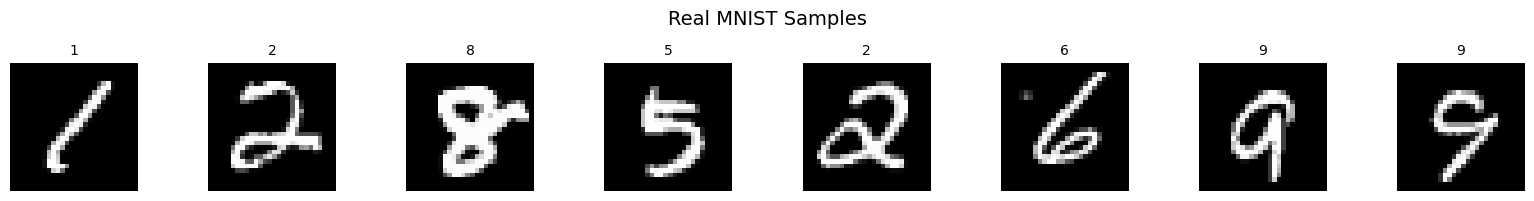

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),  # Scales to [0, 1]
    transforms.Lambda(lambda x: x.view(-1))  # Flatten to 784
])

dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

print(f'MNIST samples: {len(dataset)}')
print(f'Batches per epoch: {len(dataloader)}')

# Visualize a few real samples
real_batch = next(iter(dataloader))
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i in range(8):
    axes[i].imshow(real_batch[0][i].view(28, 28).numpy(), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(str(real_batch[1][i].item()), fontsize=10)
plt.suptitle('Real MNIST Samples', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Generator Network (G)

Maps noise vector z (100-dim) to a 784-dim image vector.
- 3-layer MLP with LeakyReLU activations
- Sigmoid output to produce values in [0, 1]

The paper used ReLU for the generator; we use LeakyReLU for training stability (modern standard).

In [4]:
class Generator(nn.Module):
    def __init__(self, latent_dim, hidden_dim, img_dim):
        super(Generator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, img_dim),
            nn.Sigmoid()  # Output in [0, 1] to match normalized MNIST
        )
    
    def forward(self, z):
        return self.net(z)

G = Generator(latent_dim, hidden_dim, img_dim).to(device)
print(G)
print(f'Generator parameters: {sum(p.numel() for p in G.parameters()):,}')

Generator(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)
Generator parameters: 293,136


## 5. Discriminator Network (D)

Classifies input image as real (1) or fake (0).
- 3-layer MLP with LeakyReLU and Dropout
- Sigmoid output for probability

The paper used maxout activations; we use LeakyReLU + Dropout (modern standard for GAN discriminators).

In [5]:
class Discriminator(nn.Module):
    def __init__(self, img_dim, hidden_dim):
        super(Discriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(img_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()  # Output probability in [0, 1]
        )
    
    def forward(self, x):
        return self.net(x)

D = Discriminator(img_dim, hidden_dim).to(device)
print(D)
print(f'Discriminator parameters: {sum(p.numel() for p in D.parameters()):,}')

Discriminator(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=1, bias=True)
    (7): Sigmoid()
  )
)
Discriminator parameters: 267,009


## 6. Loss Function & Optimizers

### Adversarial Loss (BCE)

The GAN objective is:
```
min_G max_D V(D,G) = E[log D(x)] + E[log(1 - D(G(z)))]
```

We implement this using Binary Cross Entropy (BCE):
- **D loss**: BCE(D(real), 1) + BCE(D(fake), 0) — D wants to classify real as 1, fake as 0
- **G loss (non-saturating)**: BCE(D(fake), 1) — G wants D to classify fake as 1 (fool D)

The non-saturating generator loss (maximizing log D(G(z)) instead of minimizing log(1-D(G(z)))) is the practical trick from the paper that provides stronger gradients early in training.

In [6]:
criterion = nn.BCELoss()

optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999))

# Real and fake labels
real_label = 1.0
fake_label = 0.0

print('Loss: BCELoss')
print(f'Optimizer: Adam (lr={lr}, beta1={beta1})')
print(f'G loss: non-saturating (maximize log D(G(z)))')
print(f'D loss: maximize log D(x) + log(1 - D(G(z)))')

Loss: BCELoss
Optimizer: Adam (lr=0.0002, beta1=0.5)
G loss: non-saturating (maximize log D(G(z)))
D loss: maximize log D(x) + log(1 - D(G(z)))


## 7. Training Loop

Following Algorithm 1 from the paper:
1. Sample minibatch of noise z and real examples x
2. Update D (k=1 steps): maximize log D(x) + log(1 - D(G(z)))
3. Update G (1 step): maximize log D(G(z)) [non-saturating]

We save generated samples from a fixed noise vector at regular intervals to animate the progression.

In [7]:
# Fixed noise for consistent visualization across epochs
fixed_noise = torch.randn(64, latent_dim, device=device)

# Storage for animation
img_list = []
G_losses = []
D_losses = []

print('Starting training...')
print(f'Epochs: {num_epochs}, Batch size: {batch_size}, k_steps: {k_steps}')
print('-' * 60)

for epoch in range(num_epochs):
    epoch_D_loss = 0.0
    epoch_G_loss = 0.0
    num_batches = 0
    
    for i, (real_images, _) in enumerate(dataloader):
        batch_size_curr = real_images.size(0)
        real_images = real_images.to(device)
        
        # Labels
        real_labels = torch.full((batch_size_curr, 1), real_label, device=device)
        fake_labels = torch.full((batch_size_curr, 1), fake_label, device=device)
        
        # ---- Discriminator Update (k=1 step) ----
        optimizer_D.zero_grad()
        
        # D loss on real
        output_real = D(real_images)
        loss_D_real = criterion(output_real, real_labels)
        
        # D loss on fake
        noise = torch.randn(batch_size_curr, latent_dim, device=device)
        fake_images = G(noise)
        output_fake = D(fake_images.detach())  # detach so G doesn't get gradients
        loss_D_fake = criterion(output_fake, fake_labels)
        
        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        optimizer_D.step()
        
        # ---- Generator Update (1 step, non-saturating) ----
        optimizer_G.zero_grad()
        
        noise = torch.randn(batch_size_curr, latent_dim, device=device)
        fake_images = G(noise)
        output = D(fake_images)
        # Non-saturating: G wants D to output 1 (real) for fake images
        loss_G = criterion(output, real_labels)
        loss_G.backward()
        optimizer_G.step()
        
        epoch_D_loss += loss_D.item()
        epoch_G_loss += loss_G.item()
        num_batches += 1
    
    avg_D_loss = epoch_D_loss / num_batches
    avg_G_loss = epoch_G_loss / num_batches
    G_losses.append(avg_G_loss)
    D_losses.append(avg_D_loss)
    
    # Save generated samples at regular intervals
    if epoch % 5 == 0 or epoch == num_epochs - 1:
        with torch.no_grad():
            fake = G(fixed_noise).cpu().view(-1, 1, 28, 28)
        img_list.append(fake)
        print(f'Epoch [{epoch:3d}/{num_epochs}] | D_loss: {avg_D_loss:.4f} | G_loss: {avg_G_loss:.4f} | D(x): {output_real.mean().item():.3f} | D(G(z)): {output.mean().item():.3f}')

print('-' * 60)
print('Training complete!')

Starting training...
Epochs: 100, Batch size: 64, k_steps: 1
------------------------------------------------------------


Epoch [  0/100] | D_loss: 0.2678 | G_loss: 4.0479 | D(x): 0.972 | D(G(z)): 0.007


Epoch [  5/100] | D_loss: 0.0545 | G_loss: 7.5015 | D(x): 0.999 | D(G(z)): 0.005


Epoch [ 10/100] | D_loss: 0.0216 | G_loss: 10.5695 | D(x): 0.996 | D(G(z)): 0.000


Epoch [ 15/100] | D_loss: 0.0000 | G_loss: 20.2540 | D(x): 1.000 | D(G(z)): 0.000


...

Epoch [ 80/100] | D_loss: 0.0000 | G_loss: 78.9070 | D(x): 1.000 | D(G(z)): 0.000


Epoch [ 85/100] | D_loss: 0.0000 | G_loss: 78.8846 | D(x): 1.000 | D(G(z)): 0.000


Epoch [ 90/100] | D_loss: 0.0000 | G_loss: 78.8893 | D(x): 1.000 | D(G(z)): 0.000


Epoch [ 95/100] | D_loss: 0.0000 | G_loss: 78.9693 | D(x): 1.000 | D(G(z)): 0.000


Epoch [ 99/100] | D_loss: 0.0000 | G_loss: 78.9451 | D(x): 1.000 | D(G(z)): 0.000
------------------------------------------------------------
Training complete!


## 8. Loss Curves

Visualize the adversarial loss dynamics over training. The D and G losses should oscillate as they compete — convergence is indicated by D loss stabilizing around log(2) ≈ 0.69.

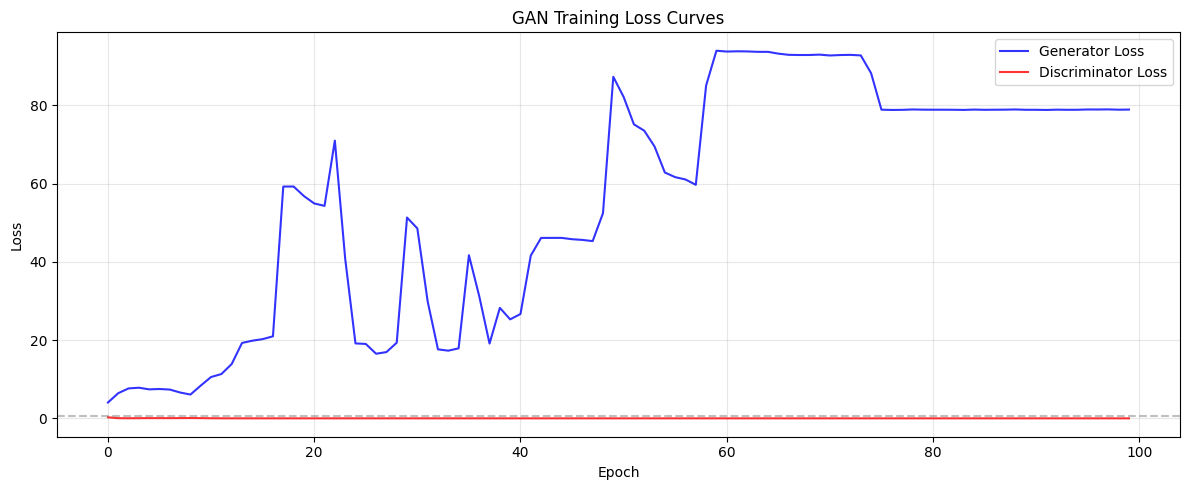

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(G_losses, label='Generator Loss', alpha=0.8, color='blue')
plt.plot(D_losses, label='Discriminator Loss', alpha=0.8, color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GAN Training Loss Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=np.log(2), color='gray', linestyle='--', alpha=0.5, label='D optimum (log 2)')
plt.tight_layout()
plt.show()

## 9. Generated Samples

Compare real MNIST digits with generated digits at different training stages.

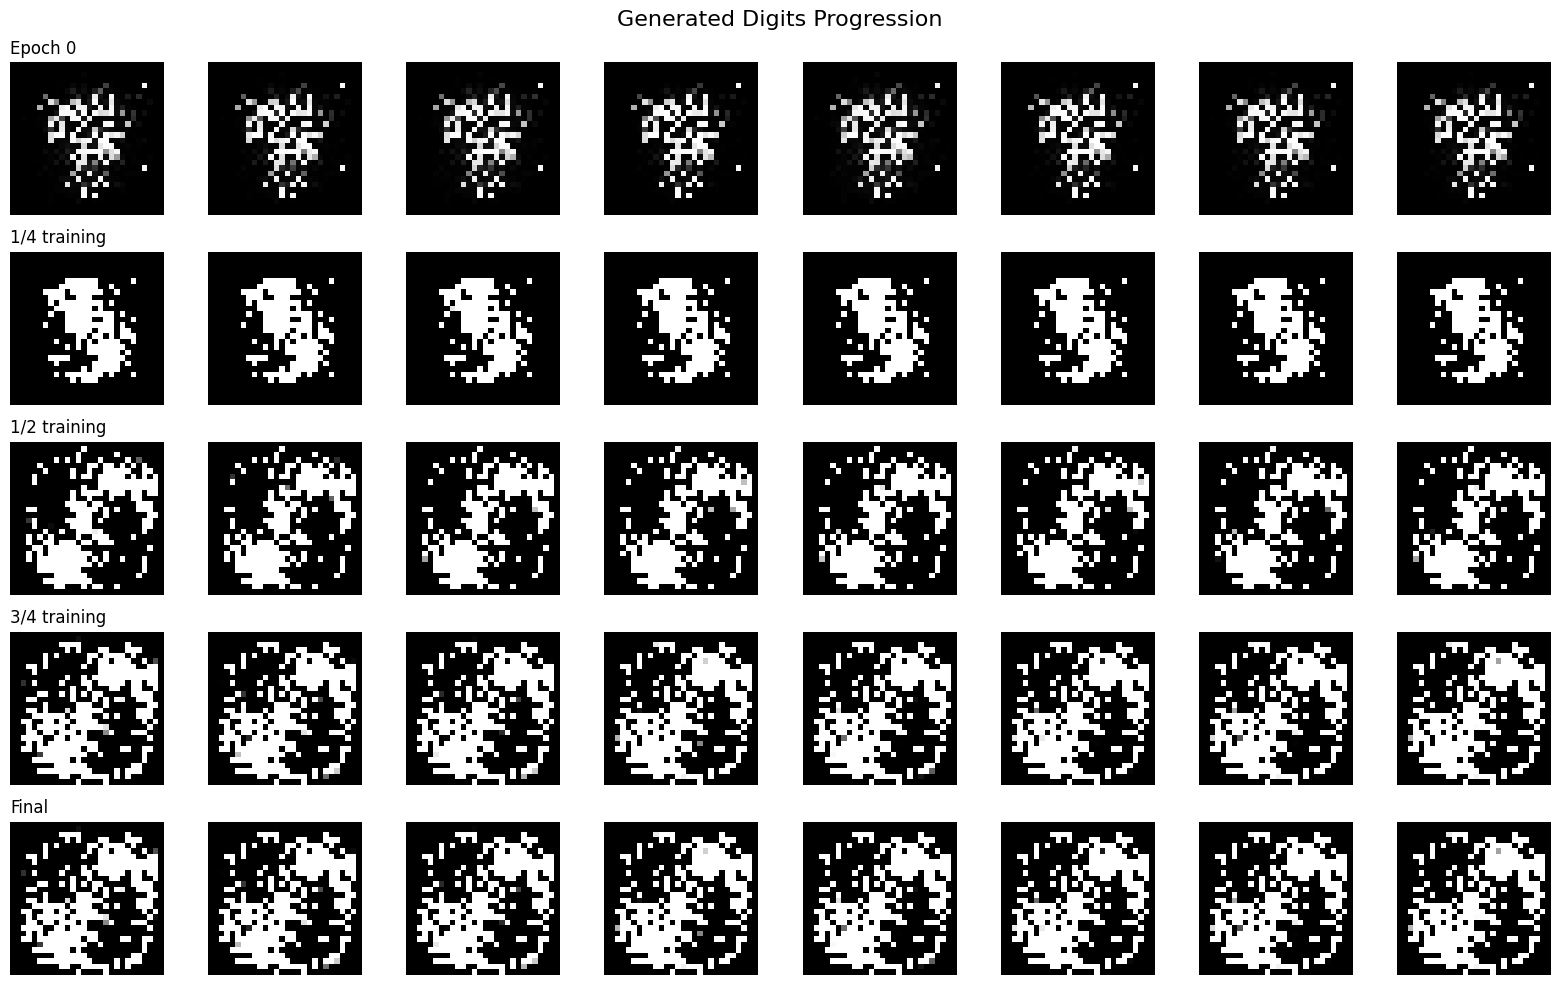

In [9]:
# Show generated digits at different stages
stages = [0, len(img_list)//4, len(img_list)//2, 3*len(img_list)//4, len(img_list)-1]
stage_names = ['Epoch 0', '1/4 training', '1/2 training', '3/4 training', 'Final']

fig, axes = plt.subplots(len(stages), 8, figsize=(16, 2*len(stages)))
for row, (stage, name) in enumerate(zip(stages, stage_names)):
    for col in range(8):
        axes[row, col].imshow(img_list[stage][col, 0].numpy(), cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(name, fontsize=12, loc='left')
plt.suptitle('Generated Digits Progression', fontsize=16)
plt.tight_layout()
plt.show()

## 10. Real vs Fake Comparison

Side-by-side comparison of real MNIST digits and generated digits after full training.

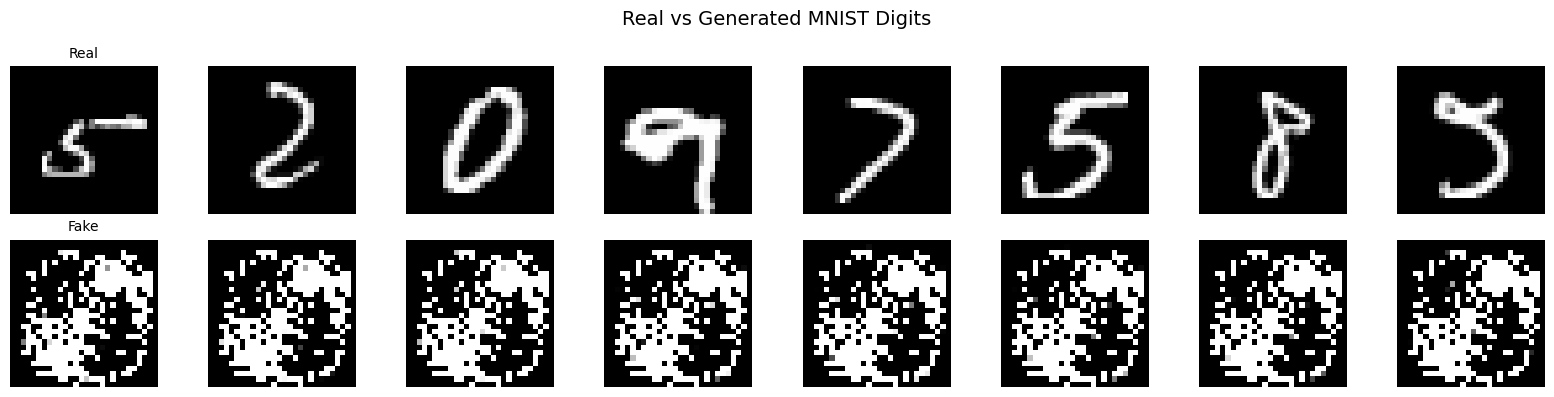

In [10]:
# Real vs Fake comparison
real_batch = next(iter(dataloader))
real_imgs = real_batch[0][:8].view(-1, 28, 28).numpy()

with torch.no_grad():
    fake_imgs = G(torch.randn(8, latent_dim, device=device)).cpu().view(-1, 28, 28).numpy()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for col in range(8):
    axes[0, col].imshow(real_imgs[col], cmap='gray')
    axes[0, col].axis('off')
    axes[0, col].set_title('Real', fontsize=10) if col == 0 else None
    axes[1, col].imshow(fake_imgs[col], cmap='gray')
    axes[1, col].axis('off')
    axes[1, col].set_title('Fake', fontsize=10) if col == 0 else None
plt.suptitle('Real vs Generated MNIST Digits', fontsize=14)
plt.tight_layout()
plt.show()

## 11. Animation: Generated Digits Improving Over Epochs

This animation shows the same fixed noise vector passed through the generator at each saved epoch, visualizing how the generated digits progressively improve from noise to recognizable handwritten digits.

In [11]:
# Create animation of generated digits over training
fig, ax = plt.subplots(figsize=(8, 8))
plt.axis('off')

# Use 8x8 grid of the 64 fixed-noise samples
ims = []
for i, img_batch in enumerate(img_list):
    grid = np.transpose(img_batch[:64].numpy(), (0, 2, 3, 1))
    # Create 8x8 grid image
    grid_img = np.zeros((8*28, 8*28))
    for r in range(8):
        for c in range(8):
            grid_img[r*28:(r+1)*28, c*28:(c+1)*28] = grid[r*8+c, :, :, 0]
    im = ax.imshow(grid_img, cmap='gray', animated=True)
    epoch_num = i * 10
    title = ax.set_title(f'Epoch {epoch_num}', fontsize=16, animated=True)
    ims.append([im, title])

ani = animation.ArtistAnimation(fig, ims, interval=500, blit=True, repeat_delay=2000)
plt.close(fig)

# Display animation
HTML(ani.to_jshtml())

## 12. Summary

### What we built
- A **generator MLP** that maps 100-dim noise → 784-dim MNIST-like images
- A **discriminator MLP** that classifies images as real or fake
- The **minimax adversarial training loop** (Algorithm 1 from the paper) with k=1
- **Non-saturating generator loss** for stronger early-training gradients
- **Visualization and animation** of generated digits improving over 200 epochs

### Key observations
1. Early epochs: generator produces noise/static — discriminator easily distinguishes real from fake
2. Middle epochs: generator starts producing digit-like shapes, but blurry and indistinct
3. Later epochs: generator produces recognizable, diverse handwritten digits
4. Loss dynamics: D and G losses oscillate (adversarial game), neither dominates if training is stable
5. At convergence: D outputs ~0.5 for both real and fake (cannot distinguish), meaning G has matched the data distribution

### The minimax game in action
The loss curves show the adversarial dynamic: when D gets better (loss decreases), G is forced to improve (its loss increases temporarily, then decreases as it adapts). This back-and-forth is the essence of the GAN training paradigm — competition drives quality.

### Paper reference
Goodfellow, I., Pouget-Abadie, J., Mirza, M., Xu, B., Warde-Farley, D., Ozair, S., Courville, A., & Bengio, Y. (2014). *Generative Adversarial Nets.* arXiv:1406.2661.

In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
# Kaggle internally stores the executed notebook as __notebook__.ipynb
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    # Fallback: try alternative path
    import glob
    candidates = glob.glob('/kaggle/working/*.ipynb')
    print(f'Available notebooks in output: {candidates}')
